In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,f1_score


In [3]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df = df[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]

# Fill missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Convert categorical variables
df = pd.get_dummies(df, columns=['Sex','Embarked'], drop_first=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_14856\2268119354.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_14856\2268119354.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [6]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


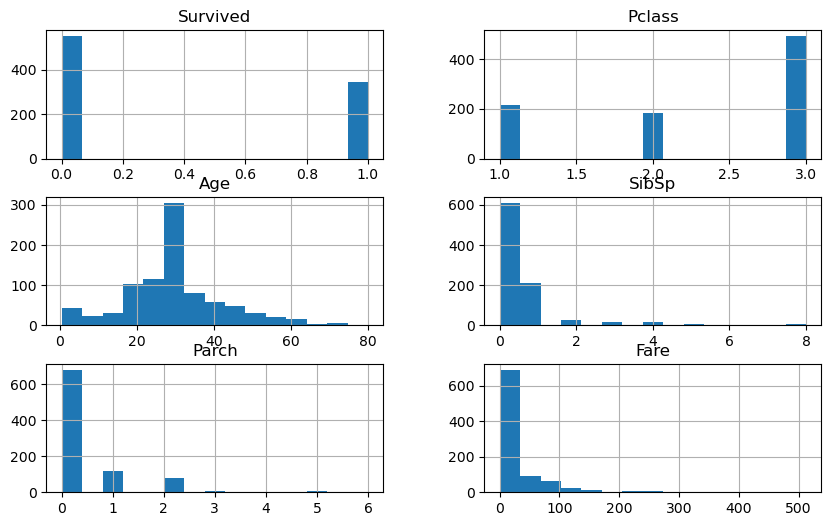

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

df.hist(bins=15,figsize=(10,6))
plt.show()

In [12]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
#Baseline Model
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print("Baseline Accuracy:", baseline_accuracy)
baseline_f1 = f1_score(y_test, baseline_pred)

print("Baseline F1 Score:", baseline_f1)

Baseline Accuracy: 0.8100558659217877
Baseline F1 Score: 0.7638888888888888


In [18]:
print(classification_report(y_test, baseline_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [26]:
#Improvement Method 1 Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaled_model = LogisticRegression(max_iter=1000)

scaled_model.fit(X_train_scaled, y_train)

scaled_pred = scaled_model.predict(X_test_scaled)

scaled_accuracy = accuracy_score(y_test, scaled_pred)

print("Accuracy after Feature Scaling:", scaled_accuracy)
scaled_f1 = f1_score(y_test, scaled_pred)

print("Scaled Model F1 Score:", scaled_f1)

Accuracy after Feature Scaling: 0.8100558659217877
Scaled Model F1 Score: 0.7638888888888888


In [24]:
#Improvement 2 Hyperparameter Tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']}

grid_search = GridSearchCV(LogisticRegression(),param_grid,cv=5)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
tuned_predictions = best_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, tuned_predictions)

print("Best Parameters:", grid_search.best_params_)
print("Accuracy after Hyperparameter Tuning:", tuned_accuracy)
tuned_f1 = f1_score(y_test, tuned_pred)

print("Tuned Model F1 Score:", tuned_f1)


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best Parameters: {'C': 1, 'solver': 'liblinear'}
Accuracy after Hyperparameter Tuning: 0.7821229050279329
Tuned Model F1 Score: 0.7299270072992701


In [25]:
#comparison
print("Baseline Accuracy:", baseline_accuracy)
print("Baseline F1:", baseline_f1)

print("Scaled Accuracy:", scaled_accuracy)
print("Scaled F1:", scaled_f1)

print("Tuned Accuracy:", tuned_accuracy)
print("Tuned F1:", tuned_f1)

Baseline Accuracy: 0.8100558659217877
Baseline F1: 0.7638888888888888
Scaled Accuracy: 0.8100558659217877
Scaled F1: 0.7638888888888888
Tuned Accuracy: 0.7821229050279329
Tuned F1: 0.7299270072992701
